In [186]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [192]:
df = pd.read_csv("datasets/wine_data.csv", header=None, usecols=[0,1,2])
df.columns = ['Class label', 'Alcohol', 'Malic acid']

In [193]:
df

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


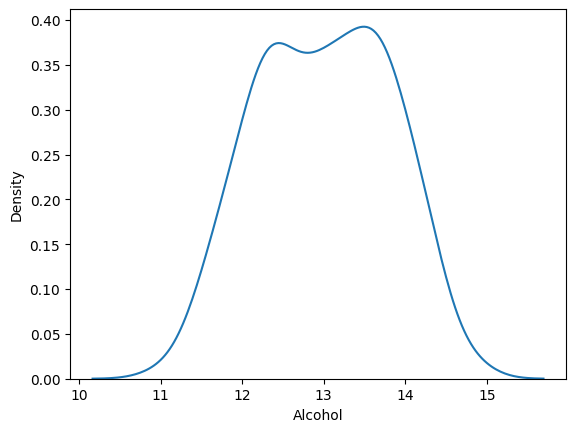

In [195]:
sns.kdeplot(df['Alcohol']);

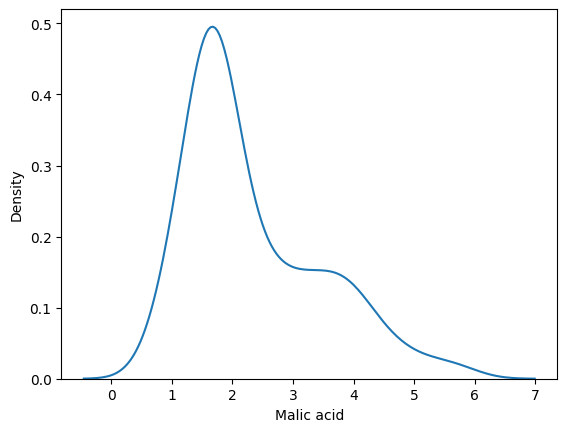

In [197]:
sns.kdeplot(df['Malic acid']);

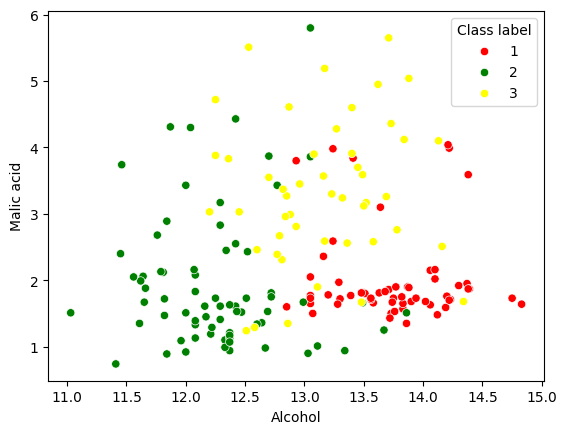

In [203]:
sns.scatterplot(x=df['Alcohol'], y=df['Malic acid'], hue=df['Class label'], palette={1:'red', 2:'green', 3:'yellow'});

In [207]:
X = df.iloc[:, 1:3]
y = df.iloc[:, 0:1]

In [231]:
y.sample(3)

,Class label
172,3
109,2
77,2


In [209]:
X.shape, y.shape

((178, 2), (178, 1))

In [210]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((124, 2), (54, 2), (124, 1), (54, 1))

In [211]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [217]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [220]:
X_test_scaled.sample(3)

,Alcohol,Malic acid
51,0.661290,0.567227
33,0.854839,0.661765
27,0.303763,0.151261


In [223]:
np.round(X_train.describe(), 1), np.round(X_train_scaled.describe(), 1)

(       Alcohol  Malic acid
 count    124.0       124.0
 mean      13.0         2.4
 std        0.8         1.1
 min       11.0         0.9
 25%       12.4         1.6
 50%       13.0         1.9
 75%       13.6         3.2
 max       14.8         5.6,
        Alcohol  Malic acid
 count    124.0       124.0
 mean       0.5         0.3
 std        0.2         0.2
 min        0.0         0.0
 25%        0.4         0.2
 50%        0.5         0.2
 75%        0.7         0.5
 max        1.0         1.0)

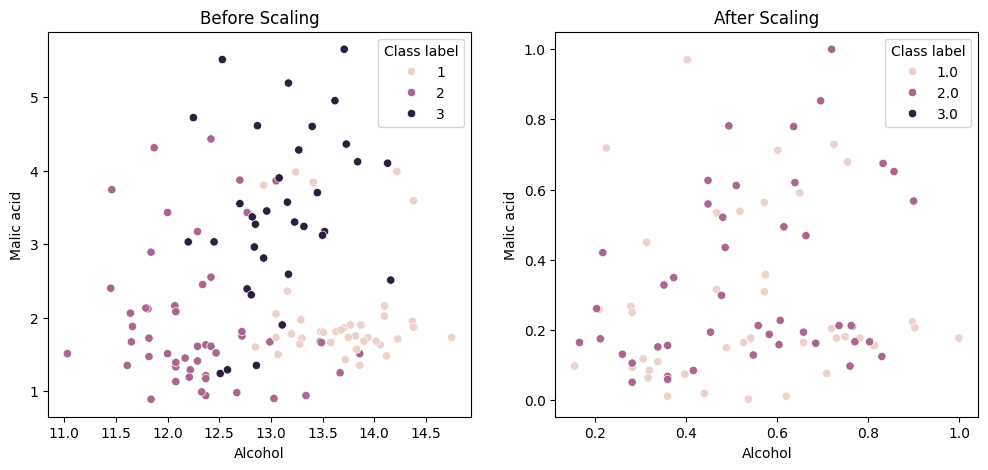

In [238]:
fig,(ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

sns.scatterplot(x = X_train['Alcohol'], y = X_train['Malic acid'], hue=y_train['Class label'], ax=ax1)
ax1.set_title("Before Scaling")

sns.scatterplot(x = X_train_scaled['Alcohol'], y = X_train_scaled['Malic acid'], hue=y_train['Class label'], ax=ax2)
ax2.set_title("After Scaling")
plt.show()


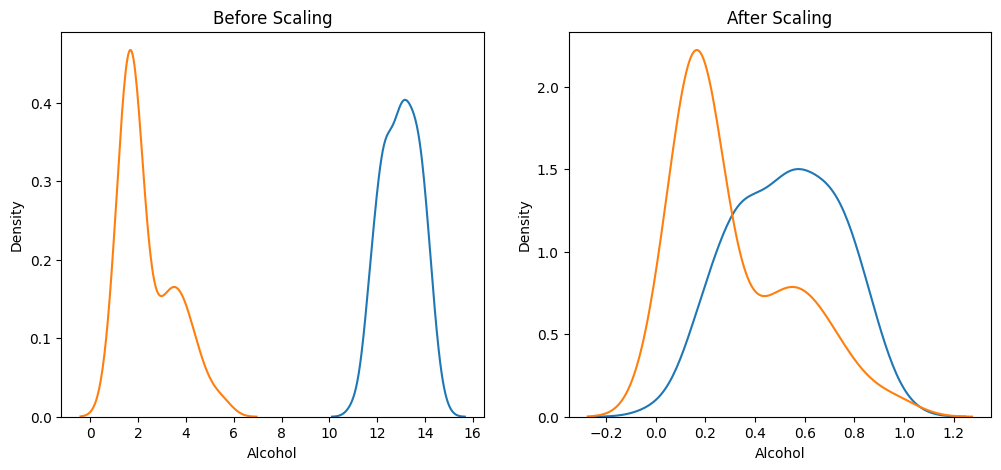

In [239]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic acid'], ax=ax1)
ax1.set_title("Before Scaling")

sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
ax2.set_title("After Scaling")

plt.show()

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

sns.kdeplot(X_train['Age'], ax = ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax = ax1)
ax1.set_title("Before Scaling")

sns.kdeplot(X_train_scaled['Age'], ax = ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax = ax2)
ax1.set_title("After Standard Scaling")

plt.show()

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

sns.kdeplot(X_train['EstimatedSalary'], ax = ax1)
ax1.set_title("Before Scaling")

sns.kdeplot(X_train['EstimatedSalary'], ax = ax2)
ax2.set_title("After Scaling")

plt.show()

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

sns.kdeplot(X_train['Age'], ax = ax1)
ax1.set_title("Before Scaling")

sns.kdeplot(X_train['Age'], ax = ax2)
ax2.set_title("After Scaling")

plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [ ]:
lr.fit(X_train, y_train)

In [ ]:
lr_scaled.fit(X_train_scaled, y_train)

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
print("Using Without scaling Data", accuracy_score(y_test, y_pred))
print("Using Scaling Data",accuracy_score(y_test, y_pred_scaled))

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [ ]:
dt.fit(X_train, y_train)

In [ ]:
dt_scaled.fit(X_train_scaled, y_train)

In [ ]:
y_pred = dt.predict(X_test)


In [ ]:
y_pred_scaled = dt_scaled.predict(X_test_scaled)

In [ ]:
print("Using Without scaling Data", accuracy_score(y_test, y_pred))
print("Using Scaling Data",accuracy_score(y_test, y_pred_scaled))

In [ ]:
new_df = pd.DataFrame({
    'Age': [5,90,95],
    'EstimatedSalary': [1000,250000,350000],
    'Purchased':[0,1,1]
})

df = pd.concat([df,new_df],ignore_index=True)

In [ ]:
df

In [ ]:
plt.scatter(x=df['Age'], y=df['EstimatedSalary']);

In [ ]:
X = df.iloc[:, 0:2]
y = df.iloc[:, -1]


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()